## Análisis de datos II - Clase 2
---

## SHAP para problemas de clasificación
---


Vamos a explicar la **contribución de las features** para la predicción en un **problema de clasificación**.

El dataset a utilizar es Iris (disponible en la biblioteca SHAP pero también en sklearn).

Para la explicación vamos a entrenar una regresión logística.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

import shap

### DATOS

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

In [3]:
# X, y = shap.datasets.iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
114,5.8,2.8,5.1,2.4
62,6.0,2.2,4.0,1.0
33,5.5,4.2,1.4,0.2
107,7.3,2.9,6.3,1.8
7,5.0,3.4,1.5,0.2


In [4]:
X_train.shape

(120, 4)

In [5]:
X_test.shape

(30, 4)

In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### EDA básico

In [7]:
df = X.copy()
df["class"] = y
df["species"] = pd.Categorical.from_codes(y, iris.target_names)

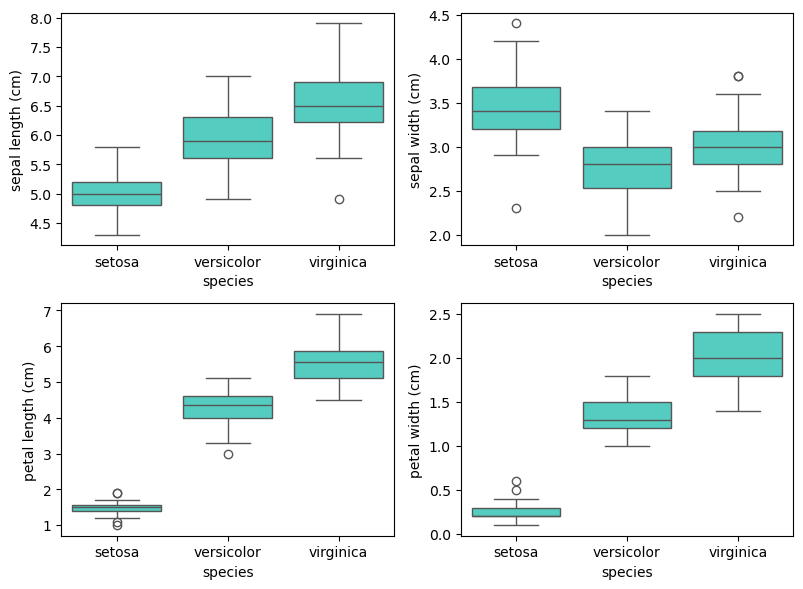

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for ax, col in zip(axes.ravel(), X.columns):
    sns.boxplot(data=df, x="species", y=col, ax=ax, color='turquoise')

plt.tight_layout()

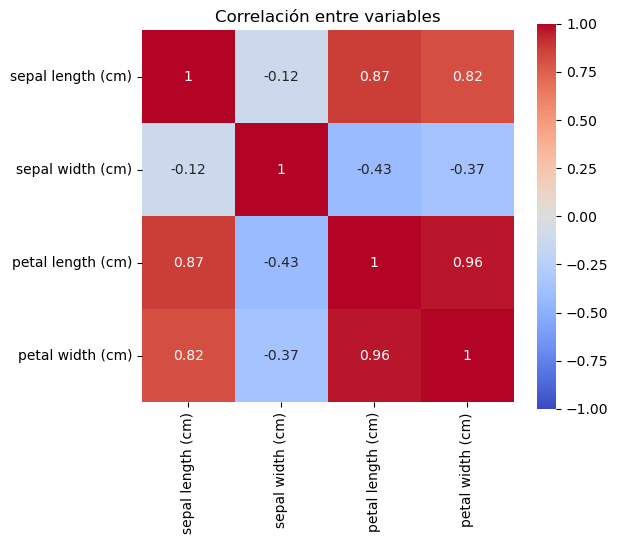

In [9]:
plt.figure(figsize=(6,5))
sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Correlación entre variables")
plt.show()

**Observaciones**

Estos gráficos permiten anticipar qué variables deberían ser relevantes para el modelo. En particular, ya se ve que petal length y petal width son mucho más discriminantes que las variables del sépalo.

### Regresión logística

In [10]:
linear_lr = sklearn.linear_model.LogisticRegression(solver="newton-cg")
linear_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [11]:
# predicciones
y_pred = linear_lr.predict(X_test)
y_pred_proba = linear_lr.predict_proba(X_test)

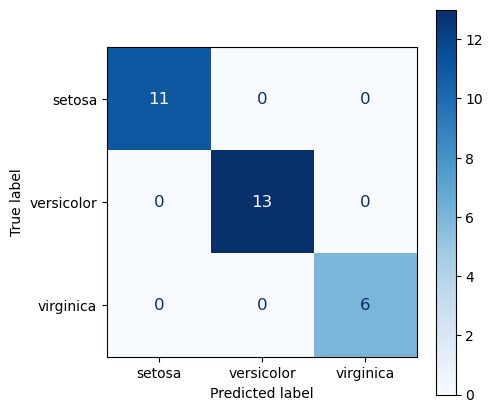

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
matrix = ConfusionMatrixDisplay.from_estimator(
    linear_lr,
    X_test,
    y_test,
    ax=ax,
    display_labels=iris.target_names,
    cmap="Blues",
    text_kw={"fontsize": 12}
)
plt.show()

El modelo clasifica correctamente todas las observaciones. Ahora queremos entender en qué se basó para tomar esas decisiones.

---
### SHAP

Creamos el explainer.

In [13]:
explainer = shap.Explainer(linear_lr.predict_proba, X_train)
explanation = explainer(X_test)

In [14]:
explanation.shape # En el caso de clasificación multiclase: (n_samples, n_features, n_classes)

(30, 4, 3)

In [15]:
shap_values     = explanation.values          # los valores SHAP
expected_values = explanation.base_values     # valor base (expected value)
data            = explanation.data            # los valores originales de X
feature_names   = explanation.feature_names   # nombres de las variables

In [16]:
shap_values[:3] # las primeras tres muestras

array([[[-0.0059135 , -0.00152222,  0.00743572],
        [-0.00575924,  0.00403729,  0.00172195],
        [-0.28977531,  0.04600504,  0.24377027],
        [-0.00729912, -0.29939798,  0.3066971 ]],

       [[-0.012617  ,  0.00675456,  0.00586243],
        [-0.0319398 ,  0.02263237,  0.00930743],
        [-0.25088646,  0.49751293, -0.24662647],
        [-0.00103118,  0.12758652, -0.12655535]],

       [[ 0.00782286, -0.01785369,  0.01003082],
        [ 0.04808429, -0.03953723, -0.00854707],
        [ 0.61412965, -0.38490385, -0.2292258 ],
        [ 0.00811153,  0.14537411, -0.15348564]]])

In [17]:
expected_values[:3] # tantos 'expected values' como clases

array([[0.30886247, 0.30990982, 0.38122771],
       [0.30886247, 0.30990982, 0.38122771],
       [0.30886247, 0.30990982, 0.38122771]])

#### Vamos a usar SHAP para explicar las salidas del modelo para la primera observación.

In [18]:
print("Observación (la primera del dataset de test):")
display(X_test.iloc[[0]])

print(f"Valor real: {y_test.iloc[0]}")
print(f"Predicción: {y_pred[0]}")
print("Pred.proba:")
for clase, p in zip(linear_lr.classes_, y_pred_proba[0]):
    print(f"{clase}: {p:.2f}")

Observación (la primera del dataset de test):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
114,5.8,2.8,5.1,2.4


Valor real: 2
Predicción: 2
Pred.proba:
0: 0.00
1: 0.06
2: 0.94


En clasificación multiclase, hay una salida por cada clase.
SHAP necesita saber cuál de ellas queremos explicar.

In [19]:
for clase in(0,1,2):
    phi = shap_values[0, :, clase] # primera obs, todas las features
    print(f"Clase {clase}")
    print(f"    base value: {expected_values[0, clase]}")
    print(f"    phi: {phi}")
    print(f"    shape value: {expected_values[0, clase] + phi.sum():.3f}")

Clase 0
    base value: 0.3088624723014308
    phi: [-0.0059135  -0.00575924 -0.28977531 -0.00729912]
    shape value: 0.000
Clase 1
    base value: 0.30990981684951685
    phi: [-0.00152222  0.00403729  0.04600504 -0.29939798]
    shape value: 0.059
Clase 2
    base value: 0.38122771084905227
    phi: [0.00743572 0.00172195 0.24377027 0.3066971 ]
    shape value: 0.941


#### Veamos esta información con plots de cascada.

La clase predicha para esta observación es 2 (Virginica). `pred_proba` es 0,94. Veamos cómo contribuyó cada feature para llegar a este valor.

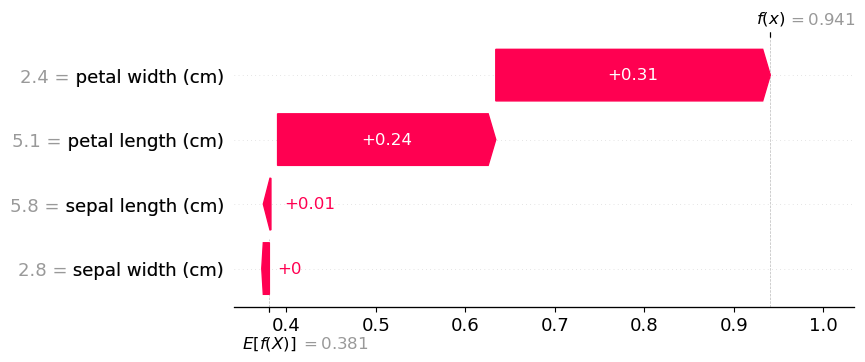

In [20]:
shap.plots.waterfall(explanation[0,:, 2]) # clase 'virginica' (es la clase predicha para esta observación)

Ahora veamos cómo contribuyeron las features para que las otras probabilidades den valores cercanos a cero. 

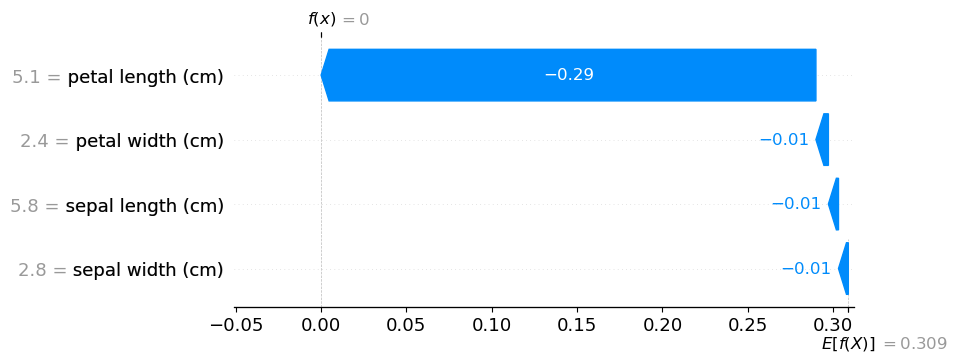

In [21]:
shap.plots.waterfall(explanation[0,:, 0]) # clase 'setosa'

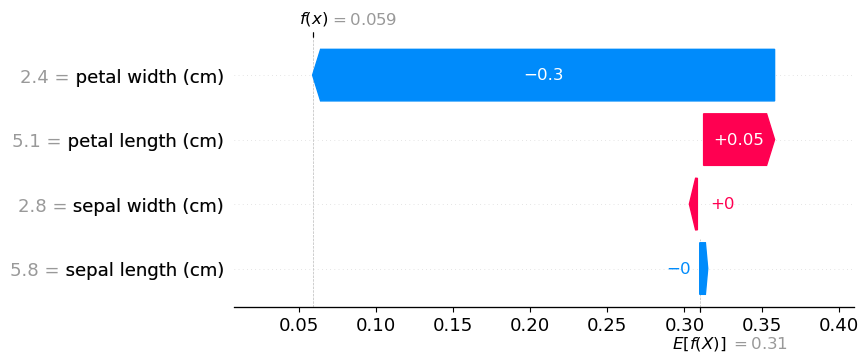

In [22]:
shap.plots.waterfall(explanation[0,:, 1]) # clase 'versicolor'

**OBSERVACIÓN**

Las contribuciones cambian según qué clase estemos explicando. En la observación elegida, para Virginica, petal length y width empujan la predicción hacia arriba; para Setosa, las mismas variables la empujan hacia abajo.

Para una observación dada, cada feature no tiene un único "SHAP value", tiene uno por salida (o clase).

---
## Force plots

Los **force plots** son otra forma de ver la explicación de una predicción.

In [23]:
shap.initjs() # para activar la representación JavaScript interactiva de SHAP.

In [24]:
shap.plots.force(explanation[0,:, 0]) # clase 'setosa'

In [25]:
shap.plots.force(explanation[0,:, 1]) # clase 'versicolor'

In [26]:
shap.plots.force(explanation[0,:, 2]) # clase 'virginica'

Con los force plots también se puede ver la contribución para todas las predicciones. Es un stack de todos los valores individuales.

Por ejemplo, podemos ver cómo contribuyen las features para predecir la clase 2 - Virginica

In [27]:
shap.plots.force(explanation[:,:,2])

---
## Beeswarm plot

El **beeswarm plot** acepta una matriz de dos dimensiones: (n_muestras, n_features)
Hay que especificar cuál clase mostrar.

clase 0


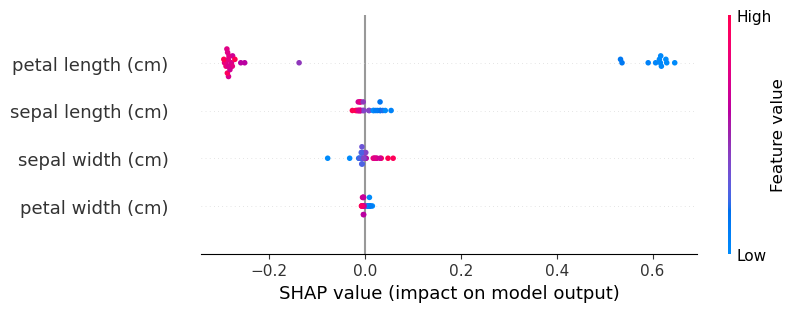

clase 1


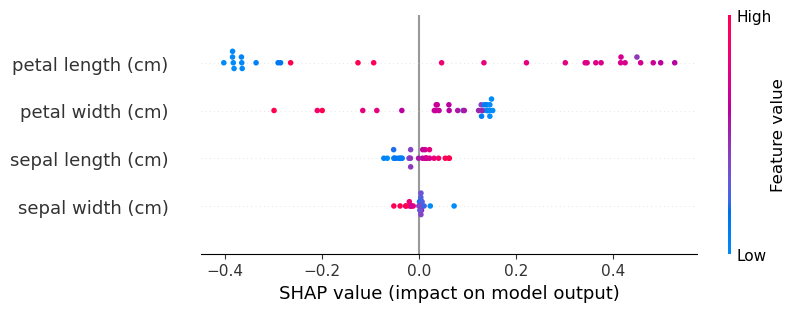

clase 2


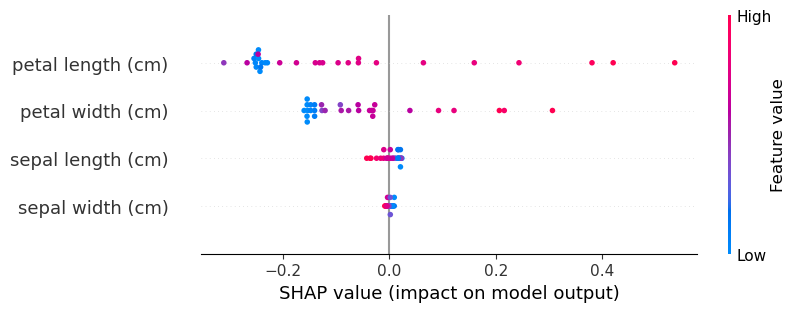

In [28]:
for clase in (0,1,2):
    print(f"clase {clase}")
    shap.plots.beeswarm(explanation[:, :, clase])